In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

<font size=5, color='red'> ch02. 한글 형태소 분석 </font>
# 1. 자연어 처리
- 자연어 : 일상적인 언어
- 자연어 처리 분야 : 
    * 자연어 이해 : 형태소 분석 -> pos-tag(postagging) -> 의미 분석, 시각화
    * 자연어 생성 : RNN, LSTM, GRU, ...., encoder-decoder 알고리즘 -> 트랜스포머 알고리즘
- 활용분야 : 트랜드 분석, 탐색적 분석, 맞춤법 검사기, 번역기, 챗봇, .....

# 2. 자연어 이해 처리 절차
- 전처리 : 단어, 어절 추출
- 분석 후보 생성 : 형태소 분리, 품사태깅(pos-tag)
- 제약 조건(불용어 처리) : 규칙 확인
- 분석 : 시각화(워드클라우드), 연관분석, RNN, LSTM, GRU, ....

# 3. 한글 형태소 분석 엔진(Konlpy,.....) 
- 공통기능 : morphs(형태소 나누기), nouns(명사추출), pos(형태소로 나눈 후 품사 태그)

- Konlpy 독보적 (pip install konlpy) -> jpype1라이브러 의존
    * HanNanum : 자바 기반 형태소 분석기(JAVA_HOME 시스템 환경 변수와 path 설정이 반드시 필요)
    * Kkma : 자바 기반 형태소 분석기(JAVA_HOME 시스템 환경 변수와 path 설정이 반드시 필요)
    * Komoran : 자바 기반 형태소 분석기(JAVA_HOME 시스템 환경 변수와 path 설정이 반드시 필요)
    * Okt, .....
- Mecab (pip install python-mecab-ko) 다국어를 지원, C++기반
    * MeCab : C++로 만든 형태소 분석기, 저사양 환경에서 사용 가능. 다국어 바인딩 지원

In [2]:
import os
os.environ.get('JAVA_HOME')

'C:\\Program Files\\Java\\jdk-17'

In [2]:
text = '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로 많이 사용되는 언어입니다.'''

## 3.1 HanNanum

In [5]:
from konlpy.tag import Hannanum
hannanum = Hannanum(jvmpath=None,
                   max_heap_size=1024, # 기본값 1024 '10m' '1g'.... limit=> '4g'
                   )
hannanum.analyze(text) # text를 형태소로 나눠서 확인하면 아래와 같이 경우의 수에 따라 결과 출력, ntag = 69로 형태소 분석 후보

[[[('아름답', 'paa'), ('지만', 'ecs')],
  [('아름답', 'paa'), ('지', 'ecs'), ('만', 'jxc')],
  [('아름답', 'paa'), ('지', 'ecx'), ('말', 'px'), ('ㄴ', 'etm')]],
 [[('다소', 'mag')], [('다소', 'ncn')]],
 [[('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하', 'xsms'), ('기', 'etn'), ('도', 'jxc')]],
 [[('하', 'pvg'), ('ㄴ', 'etm')],
  [('한', 'nnc')],
  [('한', 'ncn')],
  [('한', 'nbn')],
  [('하', 'px'), ('ㄴ', 'etm')]],
 [[('한국어', 'ncn'), ('는', 'jxc')]],
 [[('전세계', 'ncn'), ('에서', 'jca')],
  [('전세', 'ncn'), ('계', 'ncn'), ('에서', 'jca')],
  [('전', 'xp'), ('세계', 'ncn'), ('에서', 'jca')]],
 [[('13', 'nnc'), ('번', 'nbu'), ('째', 'xsnu'), ('로', 'jca')]],
 [[('많', 'paa'), ('이', 'xsa')], [('많이', 'mag')]],
 [[('사용', 'ncpa'), ('되', 'xsvn'), ('는', 'etm')]],
 [[('언어', 'ncn'), ('이', 'jp'), ('ㅂ니다', 'ef')]],
 [[('.', 'sf')], [('.', 'sy')]]]

- 구글에서 konlpy docs 검색 후(https://konlpy.org/en/latest/)
- api 메뉴 -> Comparison between POS tagging classes -> Korean POS tags comparison chart

In [6]:
# 형태소 분석 : morphs
print(hannanum.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '하', 'ㄴ', '한국어', '는', '전세계', '에서', '13번', '째', '로', '많', '이', '사용', '되', '는', '언어', '이', 'ㅂ니다', '.']


In [7]:
# 명사만 추출
print(hannanum.nouns(text))

['복잡', '한국어', '전세계', '13번', '사용', '언어']


In [8]:
# 품사 태깅
print(hannanum.pos(text, ntags=9)) # 품사의 개수(ntags) 기본값 9개, 선택 가능 : 9, 22 

[('아름답', 'P'), ('지만', 'E'), ('다소', 'M'), ('복잡', 'N'), ('하', 'X'), ('기', 'E'), ('도', 'J'), ('하', 'P'), ('ㄴ', 'E'), ('한국어', 'N'), ('는', 'J'), ('전세계', 'N'), ('에서', 'J'), ('13번', 'N'), ('째', 'X'), ('로', 'J'), ('많', 'P'), ('이', 'X'), ('사용', 'N'), ('되', 'X'), ('는', 'E'), ('언어', 'N'), ('이', 'J'), ('ㅂ니다', 'E'), ('.', 'S')]


In [9]:
print(hannanum.pos(text, ntags=22))

[('아름답', 'PA'), ('지만', 'EC'), ('다소', 'MA'), ('복잡', 'NC'), ('하', 'XS'), ('기', 'ET'), ('도', 'JX'), ('하', 'PV'), ('ㄴ', 'ET'), ('한국어', 'NC'), ('는', 'JX'), ('전세계', 'NC'), ('에서', 'JC'), ('13', 'NN'), ('번', 'NB'), ('째', 'XS'), ('로', 'JC'), ('많', 'PA'), ('이', 'XS'), ('사용', 'NC'), ('되', 'XS'), ('는', 'ET'), ('언어', 'NC'), ('이', 'JP'), ('ㅂ니다', 'EF'), ('.', 'SF')]


In [19]:
# 퀴즈 1. text에서 형용사(PA)만 추출
[data[0] for data in hannanum.pos(text, ntags=22) if data[1]=='PA']

['아름답', '많']

In [23]:
# 퀴즈 2. text에서 명사만 추출
print('품사태그가 N으로 시작하는 것 :\n',[data[0] for data in hannanum.pos(text, ntags=22) if data[1].startswith('N')])
print('Hannanum.nouns로 추출한 것 :\n',[data for data in hannanum.nouns(text)]) # nouns는 ntags=9의 결과를 반환한다

품사태그가 N으로 시작하는 것 :
 ['복잡', '한국어', '전세계', '13', '번', '사용', '언어']
Hannanum.nouns로 추출한 것 :
 ['복잡', '한국어', '전세계', '13번', '사용', '언어']


In [21]:
# 퀴즈 3. text에서 보통명사만 추출
[data[0] for data in hannanum.pos(text, ntags=22) if data[1]=='NC'] # 튜플을 받아서 인덱싱으로 구하는 것 : 스택 메모리가 적게 사용되나 속도가 느림.
[data for data, tag in hannanum.pos(text, ntags=22) if tag=='NC'] # 각 요소를 받아서 인덱싱으로 구하는 것 : 스택 메모리가 많이 사용되나 속도가 빠름.

['복잡', '한국어', '전세계', '사용', '언어']

## 3.2 Kkma

In [25]:
from konlpy.tag import Kkma
# 기본값 활용
kkma = Kkma(jvmpath=None,
            max_heap_size=1024) # '4m' , '4g'
print(kkma.morphs(text)) # 형태소 분석

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전세계', '에서', '13', '번째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다', '.']


In [26]:
kkma.nouns(text) # 명사 추출

['복잡', '한국어', '전세계', '13', '13번째', '번째', '사용', '언어']

In [32]:
# 품사 태깅
kkma.pos(text,# 파이썬에서는 ntags = 56일 때 만 기능을 제공(자바에서는 다른 값도 가능 : 자바 기반 패키지!)
         join=False, # If True, returns joined sets of morph and tag. => ('아름답', 'VA') => '아름답/VA'
        flatten=True # If False, preserves eojeols. # 2차원 리스트 반환
        ) 

[('아름답', 'VA'),
 ('지만', 'ECE'),
 ('다소', 'MAG'),
 ('복잡', 'NNG'),
 ('하', 'XSV'),
 ('기', 'ETN'),
 ('도', 'JX'),
 ('한', 'MDN'),
 ('한국어', 'NNG'),
 ('는', 'JX'),
 ('전세계', 'NNG'),
 ('에서', 'JKM'),
 ('13', 'NR'),
 ('번째', 'NNB'),
 ('로', 'JKM'),
 ('많이', 'MAG'),
 ('사용', 'NNG'),
 ('되', 'XSV'),
 ('는', 'ETD'),
 ('언어', 'NNG'),
 ('이', 'VCP'),
 ('ㅂ니다', 'EFN'),
 ('.', 'SF')]

In [35]:
# 명사 추출
tagged_text = kkma.pos(text)
print([word for word, tag in tagged_text if tag.startswith('N')]) # '번째'는 NNB tag => 제거하고 싶음
print(kkma.nouns(text))

['복잡', '한국어', '전세계', '13', '번째', '사용', '언어']
['복잡', '한국어', '전세계', '13', '13번째', '번째', '사용', '언어']


In [36]:
# 보통명사(NNG) + 고유명사(NNP)
print([word for word, tag in tagged_text if tag in ['NNG','NNP']])

['복잡', '한국어', '전세계', '사용', '언어']


## 3.3 Komoran

In [3]:
from konlpy.tag import Komoran
komoran = Komoran()

komoran.morphs(text) # 형태소 분석

['아름답',
 '지만',
 '다소',
 '복잡',
 '하',
 '기',
 '도',
 '한',
 '한국어',
 '는',
 '전',
 '세계',
 '에서',
 '13',
 '번',
 '째',
 '로',
 '많이',
 '사용',
 '되',
 '는',
 '언어',
 '이',
 'ㅂ니다',
 '.']

In [4]:
komoran.nouns(text) # 명사 추출

['한국어', '전', '세계', '번', '사용', '언어']

In [5]:
komoran.pos(text) # 품사 태깅

[('아름답', 'VA'),
 ('지만', 'EC'),
 ('다소', 'MAG'),
 ('복잡', 'XR'),
 ('하', 'XSA'),
 ('기', 'ETN'),
 ('도', 'JX'),
 ('한', 'MM'),
 ('한국어', 'NNP'),
 ('는', 'JX'),
 ('전', 'NNG'),
 ('세계', 'NNG'),
 ('에서', 'JKB'),
 ('13', 'SN'),
 ('번', 'NNB'),
 ('째', 'XSN'),
 ('로', 'JKB'),
 ('많이', 'MAG'),
 ('사용', 'NNG'),
 ('되', 'XSV'),
 ('는', 'ETM'),
 ('언어', 'NNG'),
 ('이', 'VCP'),
 ('ㅂ니다', 'EF'),
 ('.', 'SF')]

In [6]:
# 일반명사, 고유명사만 추출
[token for token ,tag in komoran.pos(text) if tag in ['NNG','NNP']]

['한국어', '전', '세계', '사용', '언어']

## 3.4 Twitter (Okt ; Open Korean Text)
- konlpy v0.4.5부터 twitter -> Okt로 바뀜

In [7]:
import konlpy
konlpy.__version__

'0.6.0'

In [12]:
from konlpy.tag import Twitter, Okt
# okt = Twitter()
# print('구 추출 :',okt.phrases(text)) # 경고메세지 "Twitter" has changed to "Okt" since KoNLPy v0.4.5.
okt = Okt()
tagged_text = okt.pos(text)
print('구 추출 :',okt.phrases(text)) # 구 추출
print('형태소 추출 :',okt.morphs(text)) # 형태소 추출
print('명사 추출 :',okt.nouns(text)) # 명사 추출
print('품사 태깅을 이용한 명사 추출 :',
     [token for token, tag in tagged_text if tag == 'Noun'])
print()
print('품사 태깅 :',tagged_text) # 품사 태깅

구 추출 : ['다소', '한국어', '전세계', '13번째', '사용', '사용되는 언어', '13', '번째', '언어']
형태소 추출 : ['아름답지만', '다소', '복잡하기도', '한', '한국어', '는', '전세계', '에서', '13', '번', '째', '로', '많이', '사용', '되는', '언어', '입니다', '.']
명사 추출 : ['다소', '한국어', '전세계', '번', '사용', '언어']
품사 태깅을 이용한 명사 추출 : ['다소', '한국어', '전세계', '번', '사용', '언어']

품사 태깅 : [('아름답지만', 'Adjective'), ('다소', 'Noun'), ('복잡하기도', 'Adjective'), ('한', 'Verb'), ('한국어', 'Noun'), ('는', 'Josa'), ('전세계', 'Noun'), ('에서', 'Josa'), ('13', 'Number'), ('번', 'Noun'), ('째', 'Suffix'), ('로', 'Josa'), ('많이', 'Adverb'), ('사용', 'Noun'), ('되는', 'Verb'), ('언어', 'Noun'), ('입니다', 'Adjective'), ('.', 'Punctuation')]


## 3.5 Mecab
- pip install python-mecab-ko

In [17]:
from mecab import MeCab
mecab = MeCab() # 힙메모리 지정 X -> C++기반의 언어로 메모리 소요가 작고 속도가 빠름

print('형태소 추출 :',mecab.morphs(text)) # 형태소 추출
print('명사 추출 :',mecab.nouns(text)) # 명사 추출
tagged_text = mecab.pos(text) # ntags 조정 불가(ntags = 43 고정)
print('품사 태깅을 이용한 명사 추출 :',
     [token for token, tag in tagged_text if tag.startswith('N')])
print('품사 태깅 :',tagged_text) # 품사 태깅

형태소 추출 : ['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '입니다', '.']
명사 추출 : ['한국어', '세계', '번', '사용', '언어']
품사 태깅을 이용한 명사 추출 : ['한국어', '세계', '번', '사용', '언어']
품사 태깅 : [('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNG'), ('는', 'JX'), ('전', 'MM'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNBC'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('입니다', 'VCP+EF'), ('.', 'SF')]


# 4. 말뭉치

In [30]:
# 영어 말뭉치
import nltk
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')
emma

'[Emma by Jane Austen 1816]\n\nVOLUME I\n\nCHAPTER I\n\n\nEmma Woodhouse, handsome, clever, and rich, with a comfortable home\nand happy disposition, seemed to unite some of the best blessings\nof existence; and had lived nearly twenty-one years in the world\nwith very little to distress or vex her.\n\nShe was the youngest of the two daughters of a most affectionate,\nindulgent father; and had, in consequence of her sister\'s marriage,\nbeen mistress of his house from a very early period.  Her mother\nhad died too long ago for her to have more than an indistinct\nremembrance of her caresses; and her place had been supplied\nby an excellent woman as governess, who had fallen little short\nof a mother in affection.\n\nSixteen years had Miss Taylor been in Mr. Woodhouse\'s family,\nless as a governess than a friend, very fond of both daughters,\nbut particularly of Emma.  Between _them_ it was more the intimacy\nof sisters.  Even before Miss Taylor had ceased to hold the nominal\noffice o

In [32]:
# 한국어 말뭉치
import konlpy
# konlpy.corpus.kolaw.fileids() # 말뭉치 체크
data = konlpy.corpus.kolaw.open('constitution.txt').read()
#      = konlpy.corpus.kolaw.open('constitution.txt').readlines() # 한줄씩 list로 반환
data

'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임시정부의 법통과 불의에 항거한 4·19민주이념을 계승하고, 조국의 민주개혁과 평화적 통일의 사명에 입각하여 정의·인도와 동포애로써 민족의 단결을 공고히 하고, 모든 사회적 폐습과 불의를 타파하며, 자율과 조화를 바탕으로 자유민주적 기본질서를 더욱 확고히 하여 정치·경제·사회·문화의 모든 영역에 있어서 각인의 기회를 균등히 하고, 능력을 최고도로 발휘하게 하며, 자유와 권리에 따르는 책임과 의무를 완수하게 하여, 안으로는 국민생활의 균등한 향상을 기하고 밖으로는 항구적인 세계평화와 인류공영에 이바지함으로써 우리들과 우리들의 자손의 안전과 자유와 행복을 영원히 확보할 것을 다짐하면서 1948년 7월 12일에 제정되고 8차에 걸쳐 개정된 헌법을 이제 국회의 의결을 거쳐 국민투표에 의하여 개정한다.\n\n       제1장 총강\n  제1조 ① 대한민국은 민주공화국이다.\n②대한민국의 주권은 국민에게 있고, 모든 권력은 국민으로부터 나온다.\n  제2조 ① 대한민국의 국민이 되는 요건은 법률로 정한다.\n②국가는 법률이 정하는 바에 의하여 재외국민을 보호할 의무를 진다.\n  제3조 대한민국의 영토는 한반도와 그 부속도서로 한다.\n  제4조 대한민국은 통일을 지향하며, 자유민주적 기본질서에 입각한 평화적 통일 정책을 수립하고 이를 추진한다.\n  제5조 ① 대한민국은 국제평화의 유지에 노력하고 침략적 전쟁을 부인한다.\n②국군은 국가의 안전보장과 국토방위의 신성한 의무를 수행함을 사명으로 하며, 그 정치적 중립성은 준수된다.\n  제6조 ① 헌법에 의하여 체결·공포된 조약과 일반적으로 승인된 국제법규는 국내법과 같은 효력을 가진다.\n②외국인은 국제법과 조약이 정하는 바에 의하여 그 지위가 보장된다.\n  제7조 ① 공무원은 국민전체에 대한 봉사자이며, 국민에 대하여 책임을 진다.\n②공무원의 신분과 정치적 중립성은 법률이 정하는 바에 의하여 보장된다.\n  제8조 ① 정

In [37]:
print('영어 말뭉치 글자수 :',len(emma))
print('국어 말뭉치 글자수 :',len(data))
print('%r' %data[:50]) # 원본데이터("\n" 까지 체크하는 방법)

영어 말뭉치 글자수 : 887071
국어 말뭉치 글자수 : 18884
'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임'


# 5. 워드클라우드
- pip install wordcloud

## 5.1 영문

In [41]:
# 말뭉치에서 단어 추출(특수 문자 제외)
from nltk.tokenize import RegexpTokenizer
from nltk.tag import pos_tag
ret = RegexpTokenizer('[\w]{2,}')
words = ret.tokenize(emma)
# 고유명사 제외 명사 추출
emma_tags = pos_tag(words)
noun_list = [token for token, tag in emma_tags if tag in ('NN','NNS')]

['Emma',
 'clever',
 'home',
 'disposition',
 'blessings',
 'existence',
 'years',
 'world',
 'daughters',
 'indulgent',
 'father',
 'consequence',
 'marriage',
 'mistress',
 'house',
 'period',
 'mother',
 'remembrance',
 'caresses',
 'place',
 'woman',
 'governess',
 'mother',
 'affection',
 'years',
 'family',
 'governess',
 'fond',
 'daughters',
 'intimacy',
 'sisters',
 'office',
 'governess',
 'mildness',
 'temper',
 'restraint',
 'shadow',
 'authority',
 'friend',
 'judgment',
 'chiefly',
 'evils',
 'situation',
 'power',
 'way',
 'disposition',
 'disadvantages',
 'alloy',
 'enjoyments',
 'danger',
 'means',
 'rank',
 'misfortunes',
 'sorrow',
 'shape',
 'consciousness',
 'loss',
 'grief',
 'wedding',
 'day',
 'friend',
 'thought',
 'continuance',
 'wedding',
 'people',
 'father',
 'prospect',
 'father',
 'dinner',
 'event',
 'promise',
 'happiness',
 'friend',
 'man',
 'character',
 'fortune',
 'age',
 'manners',
 'satisfaction',
 'friendship',
 'match',
 'morning',
 'work',
 '

In [44]:
print('추출된 명사 갯수:',len(noun_list),'\t단어 종류수', len(set(noun_list)))
print('noun_list:',noun_list[:10])

추출된 명사 갯수: 22362 	단어 종류수 3498
noun_list: ['Emma', 'clever', 'home', 'disposition', 'blessings', 'existence', 'years', 'world', 'daughters', 'indulgent']


In [49]:
emma_noun = ' '.join(noun_list)
print('워드 클라우드에 필요한 내용 :',emma_noun[:100])

워드 클라우드에 필요한 내용 : Emma clever home disposition blessings existence years world daughters indulgent father consequence 


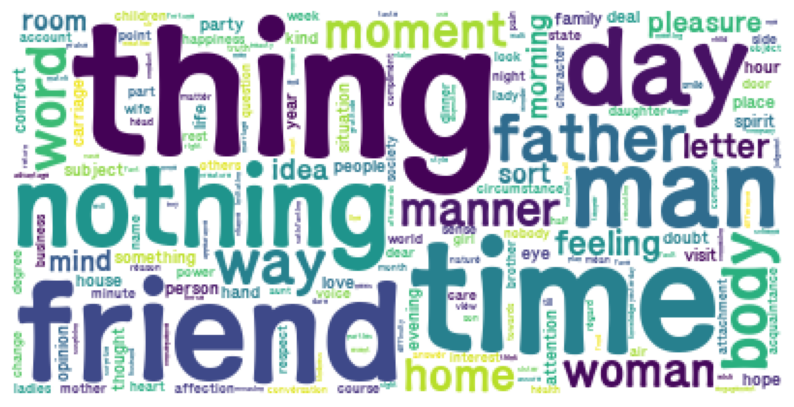

In [64]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
wordc = WordCloud(font_path='font/HMFMOLD.TTF',background_color='white')
wordc.generate(emma_noun)
plt.figure(figsize=(10,6))
plt.imshow(wordc)
plt.axis(False)
plt.show()

- matplotlib colormap : https://matplotlib.org/stable/users/explain/colors/colormaps.html

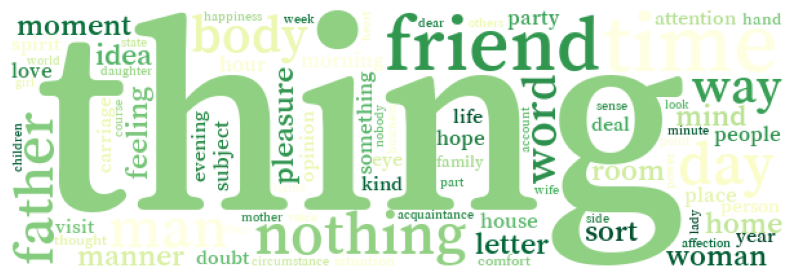

In [103]:
wordcloud = WordCloud(
    font_path='font/Song_Myung/SongMyung-Regular.ttf',
    width = 600, # 생성 이미지 가로(픽셀)
    background_color='white', # 배경색
    max_words=300, # 표시될 단어의 최대 개수
    relative_scaling=0.5, # 단어 빈도에 따른 크기 차이 조정
    colormap='YlGn',
    max_font_size=1000, # 글씨 최대 사이즈
    min_font_size= 10, # 글씨 최소 사이즈
)
wordcloud.generate(emma_noun)
plt.figure(figsize=(10,8))
plt.imshow(wordcloud)
plt.axis(False)
plt.show()

## 5.2 국문

In [98]:
# 사용 말뭉치 : data
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab import MeCab # 사용하기 용이한 방법을 찾아서 사용하면 된다
analyzer = MeCab()
noun_list = analyzer.nouns(data)
# noun_list2 = [data for data, tag in analyzer.pos(data, ntags=22) if tag in ('NC','NQ')]
data_noun = ' '.join(noun_list)

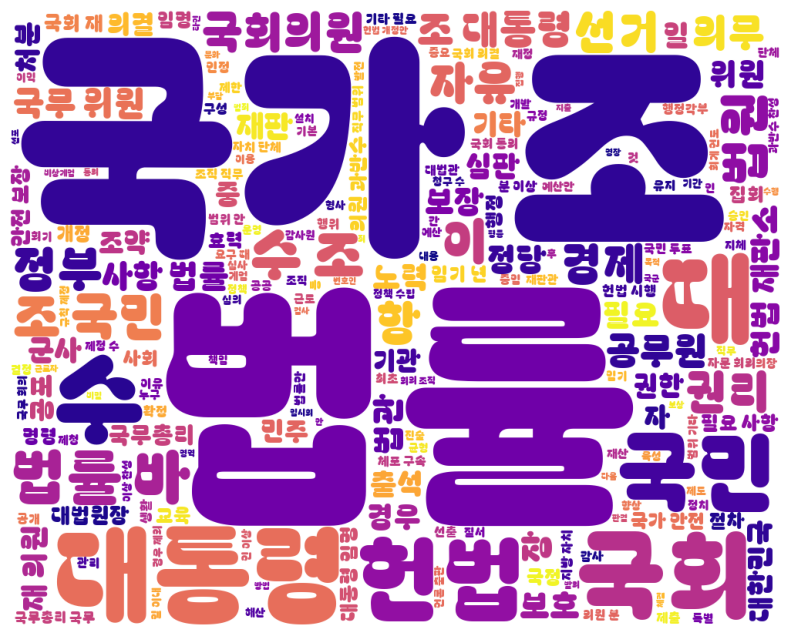

In [117]:
wordcloud = WordCloud(
    font_path='font/Bagel_Fat_One/BagelFatOne-Regular.ttf',
    width = 1000, # 생성 이미지 가로(픽셀)
    height=800,
    background_color='white', # 배경색
#     max_words=300, # 표시될 단어의 최대 개수
#     relative_scaling=0.5, # 단어 빈도에 따른 크기 차이 조정
    colormap='plasma',
#     max_font_size=80, # 글씨 최대 사이즈
#     min_font_size= 10, # 글씨 최소 사이즈
    random_state=7,
)
wordcloud.generate(data_noun)
plt.figure(figsize=(10,8))
plt.imshow(wordcloud)
plt.axis(False)
plt.show()

In [122]:
# 불용어 처리 : 불용어 지정, 불용어 사전
from wordcloud import STOPWORDS
불용어 = STOPWORDS | {'대통령', '법률'}
불용어 = {'대통령', '법률'}
불용어 = set(['대통령','법률'])
불용어

{'대통령', '법률'}

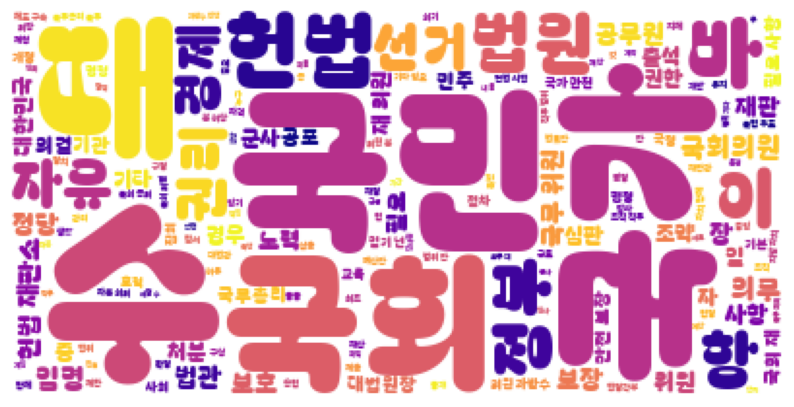

In [151]:
wordcloud = WordCloud(
    font_path='font/Bagel_Fat_One/BagelFatOne-Regular.ttf',
#     width = 200, # 생성 이미지 가로(픽셀)
#     height=100,
    background_color='white', # 배경색
#     max_words=300, # 표시될 단어의 최대 개수
#     relative_scaling=0.5, # 단어 빈도에 따른 크기 차이 조정
    colormap='plasma',
#     max_font_size=80, # 글씨 최대 사이즈
#     min_font_size= 10, # 글씨 최소 사이즈
    random_state=7,
    stopwords=불용어 | {'조'},
#     mask = shape
)
wordcloud.generate(data_noun)
plt.figure(figsize=(10,8))
plt.imshow(wordcloud)
plt.axis(False)
plt.show()

### masking 
- 워드클라우드를 지정된 마스크 이미지에 맞도록 설정

(468, 720, 3)


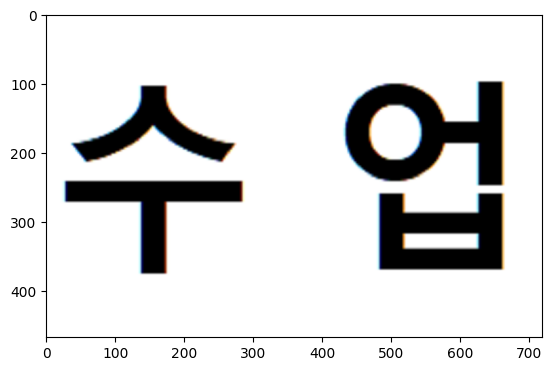

In [148]:
# 이미지를 넘파이 배열로 만드는 방법1
import cv2
# pip install opencv-contrib-python
mask = cv2.imread('data/test.png',
#                   cv2.IMREAD_GRAYSCALE,
                 )
plt.imshow(mask)
# np.array(mask)
print(mask.shape)

In [131]:
# 이미지를 넘파이 배열로 만드는 방법2
from PIL import Image
import numpy as np

In [150]:
img = Image.open('data/test.png')
# gray_img = img.convert('L')
# shape = np.array(gray_img)
mask = np.array(img)
print(mask.shape)

(468, 720, 3)


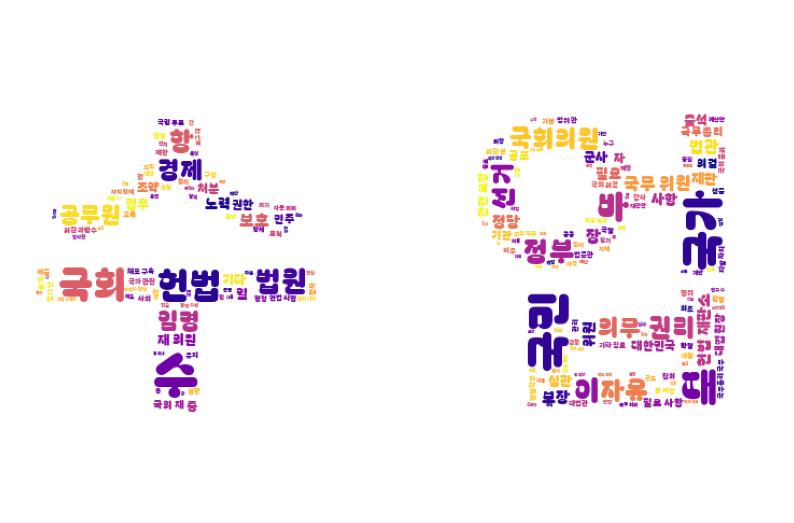

In [152]:
wordcloud = WordCloud(
    font_path='font/Bagel_Fat_One/BagelFatOne-Regular.ttf',
#     width = 200, # 생성 이미지 가로(픽셀)
#     height=100,
    background_color='white', # 배경색
#     max_words=300, # 표시될 단어의 최대 개수
#     relative_scaling=0.5, # 단어 빈도에 따른 크기 차이 조정
    colormap='plasma',
#     max_font_size=80, # 글씨 최대 사이즈
#     min_font_size= 10, # 글씨 최소 사이즈
    random_state=7,
    stopwords=불용어 | {'조'},
    mask = mask
)
wordcloud.generate(data_noun)
plt.figure(figsize=(10,8))
plt.imshow(wordcloud)
plt.axis(False)
plt.show()

In [153]:
img = Image.open('data/heart.jpg')
mask = np.array(img)
mask.shape

(1600, 1600)

In [155]:
mask2 = cv2.imread('data/heart.jpg')
mask2

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

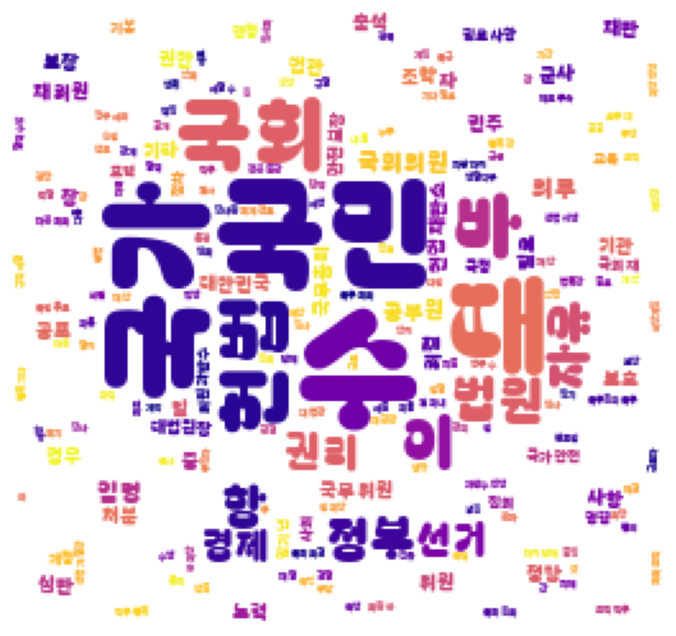

In [160]:
wordcloud = WordCloud(
    font_path='font/Bagel_Fat_One/BagelFatOne-Regular.ttf',
#     width = 200, # 생성 이미지 가로(픽셀)
#     height=100,
    background_color='white', # 배경색
#     max_words=300, # 표시될 단어의 최대 개수
#     relative_scaling=0.5, # 단어 빈도에 따른 크기 차이 조정
    colormap='plasma',
#     max_font_size=80, # 글씨 최대 사이즈
#     min_font_size= 10, # 글씨 최소 사이즈
    random_state=7,
    stopwords=불용어 | {'조'},
    mask = mask3
)
wordcloud.generate(data_noun)
plt.figure(figsize=(10,8))
plt.imshow(wordcloud)
plt.axis(False)
plt.show()

In [159]:
mask3 = cv2.imread('data/test2.jpg')
mask3.shape

(241, 257, 3)

In [161]:
mask4 = cv2.imread('data/test3.png') # cv2는 기본값으로 3차원 반환
mask4

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

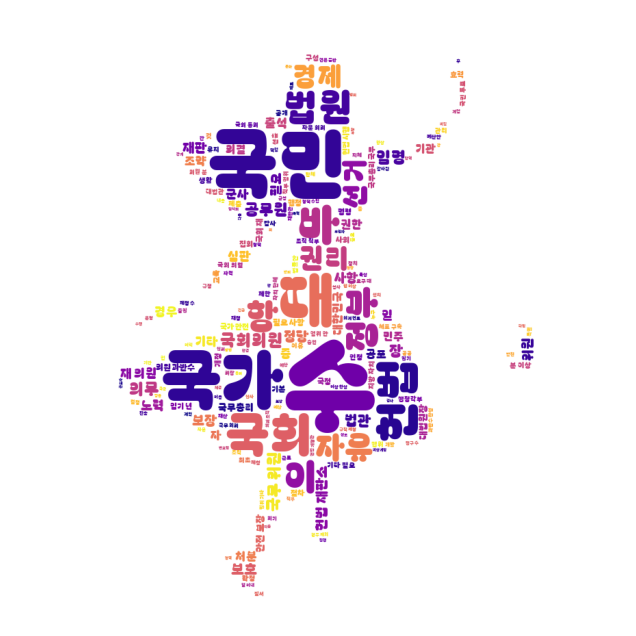

In [162]:
wordcloud = WordCloud(
    font_path='font/Bagel_Fat_One/BagelFatOne-Regular.ttf',
#     width = 200, # 생성 이미지 가로(픽셀)
#     height=100,
    background_color='white', # 배경색
#     max_words=300, # 표시될 단어의 최대 개수
#     relative_scaling=0.5, # 단어 빈도에 따른 크기 차이 조정
    colormap='plasma',
#     max_font_size=80, # 글씨 최대 사이즈
#     min_font_size= 10, # 글씨 최소 사이즈
    random_state=7,
    stopwords=불용어 | {'조'},
    mask = mask4
)
wordcloud.generate(data_noun)
plt.figure(figsize=(10,8))
plt.imshow(wordcloud)
plt.axis(False)
plt.show()

In [171]:
mask5 = np.array(Image.open('data/south_korea.png'))
mask5.shape
# plt.imshow(mask5, cmap='gray')

(1124, 720)

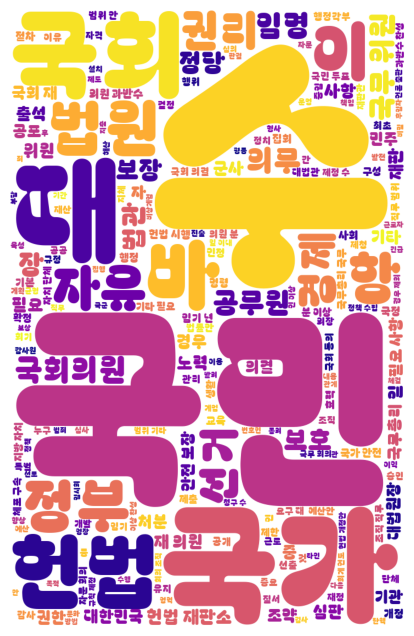

In [172]:
wordcloud = WordCloud(
    font_path='font/Bagel_Fat_One/BagelFatOne-Regular.ttf',
#     width = 200, # 생성 이미지 가로(픽셀)
#     height=100,
    background_color='white', # 배경색
#     max_words=300, # 표시될 단어의 최대 개수
#     relative_scaling=0.5, # 단어 빈도에 따른 크기 차이 조정
    colormap='plasma',
#     max_font_size=80, # 글씨 최대 사이즈
#     min_font_size= 10, # 글씨 최소 사이즈
    random_state=7,
    stopwords=불용어 | {'조'},
    mask = mask5 # 1차원 결과물에서는 의미가 없음
)
wordcloud.generate(data_noun)
plt.figure(figsize=(10,8))
plt.imshow(wordcloud)
plt.axis(False)
plt.show()

In [177]:
imgs = Image.open('data/south_korea.png')
imgs.convert('RGB')
mask5 = np.array(imgs.convert('RGB')) # convert() 속 인자 : 'L' 그레이스케일 'RGB' 3채널 'RGBA' 4채널
mask5.shape
# plt.imshow(mask5, cmap='gray')

(1124, 720, 3)

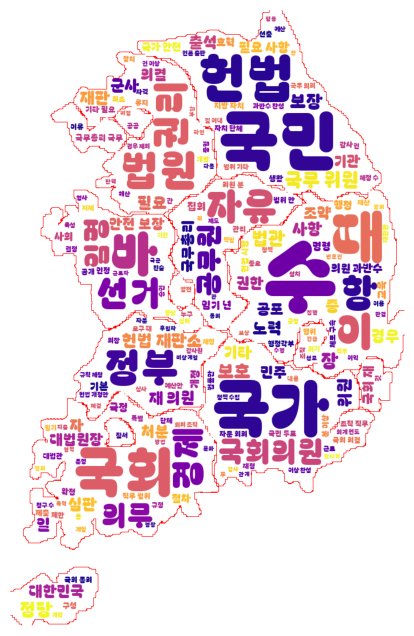

In [181]:
wordcloud = WordCloud(
    font_path='font/Bagel_Fat_One/BagelFatOne-Regular.ttf',
#     width = 200, # 생성 이미지 가로(픽셀)
#     height=100,
    background_color='white', # 배경색
#     max_words=8000, # 표시될 단어의 최대 개수
#     relative_scaling=0.5, # 단어 빈도에 따른 크기 차이 조정
    colormap='plasma',
#     max_font_size=80, # 글씨 최대 사이즈
#     min_font_size= 10, # 글씨 최소 사이즈
    random_state=7,
    stopwords=불용어 | {'조'},
    mask = mask5, # 1차원 결과물에서는 의미가 없음
    contour_color='red', # mask의 외곽선을 그려줌
    contour_width=1
)
wordcloud.generate(data_noun)
plt.figure(figsize=(10,8))
plt.imshow(wordcloud)
plt.axis(False)
plt.savefig('data/이미지샘플.png')
plt.show()

In [183]:
# 생성된 워드클라우드 저장
wordcloud.to_file('data/워드클라우드샘플.png') # plt.savefig보다 훨씬 고화질로 저장

### 단어의 빈도수 시각화

In [195]:
# 단어의 빈도수 시각화(nltk.Text)
noun_pro = [data for data in noun_list if data not in {'대통령','법률','조','수'}] # 불용어 처리는 여기서(list compregension)만 가능하다
data_Text = nltk.Text(noun_pro)

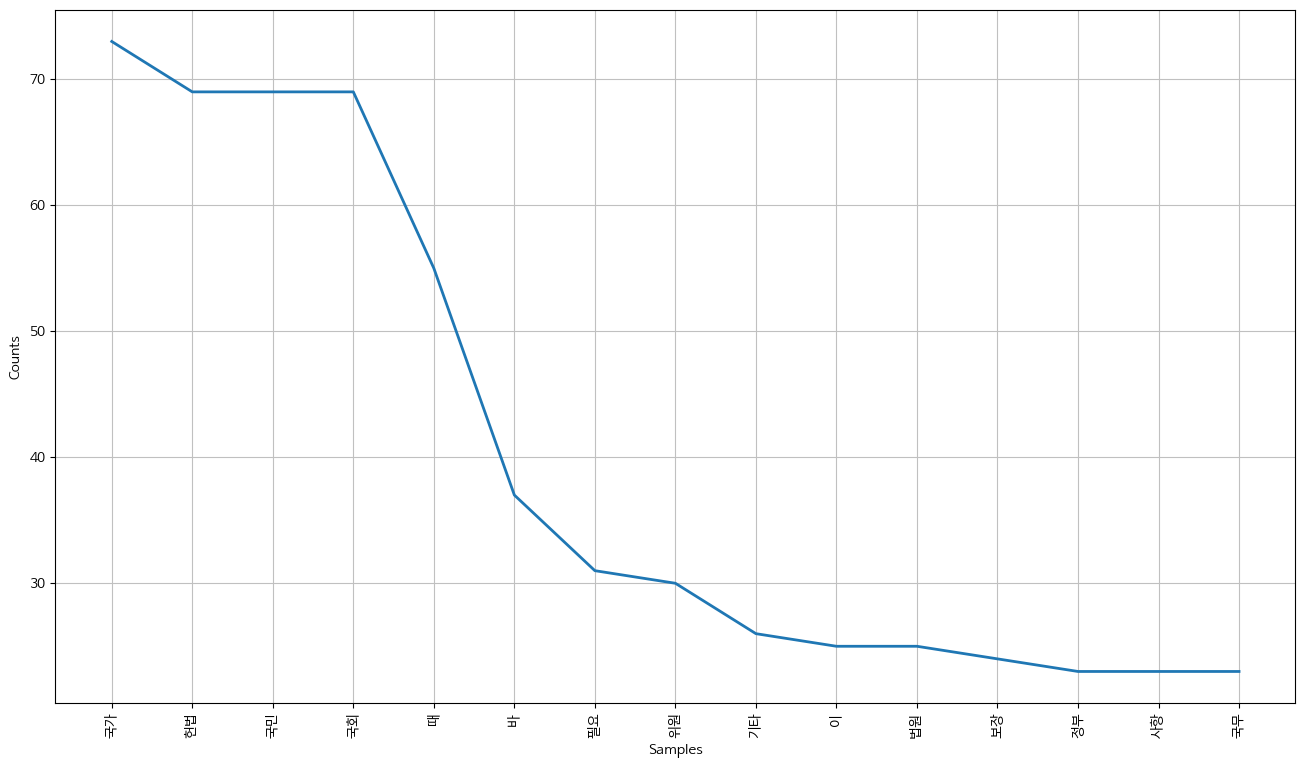

<Axes: xlabel='Samples', ylabel='Counts'>

In [200]:
plt.rc('font', family='Hancom Gothic')
plt.figure(figsize=(16,9))
data_Text.plot(15)

In [199]:
data_Text.vocab().most_common(15) # 주기를 세어서 튜플을 담은 리스트로 반환

[('국가', 73),
 ('헌법', 69),
 ('국민', 69),
 ('국회', 69),
 ('때', 55),
 ('바', 37),
 ('필요', 31),
 ('위원', 30),
 ('기타', 26),
 ('이', 25),
 ('법원', 25),
 ('보장', 24),
 ('정부', 23),
 ('사항', 23),
 ('국무', 23)]

('국가', '헌법', '국민', '국회', '때', '바', '필요', '위원', '기타', '이', '법원', '보장', '정부', '사항', '국무')
(73, 69, 69, 69, 55, 37, 31, 30, 26, 25, 25, 24, 23, 23, 23)


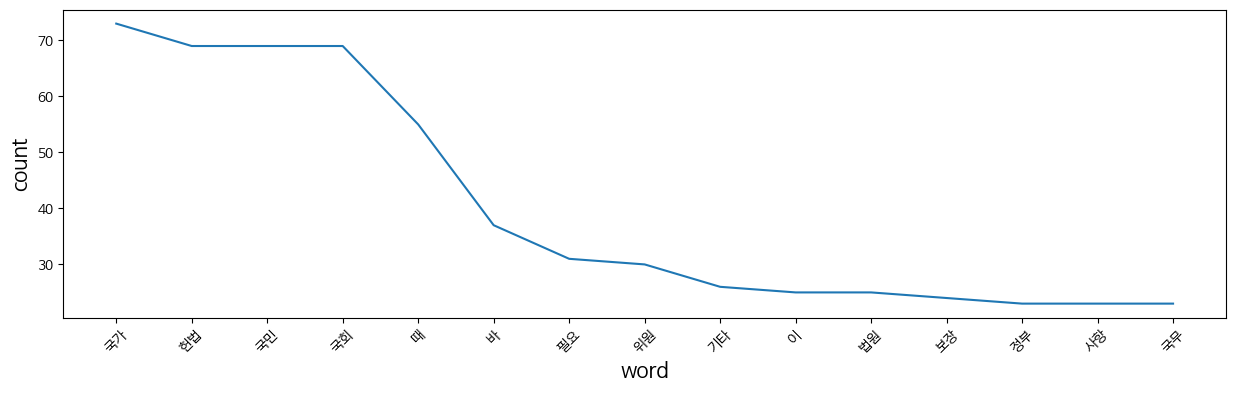

In [210]:
word, counts = zip(*data_Text.vocab().most_common(15))
print(word)
print(counts)
plt.figure(figsize=(15,4))
plt.plot(word, counts)
plt.xticks(rotation=45)
plt.xlabel('word', size=15)
plt.ylabel('count', size=15)
plt.show()

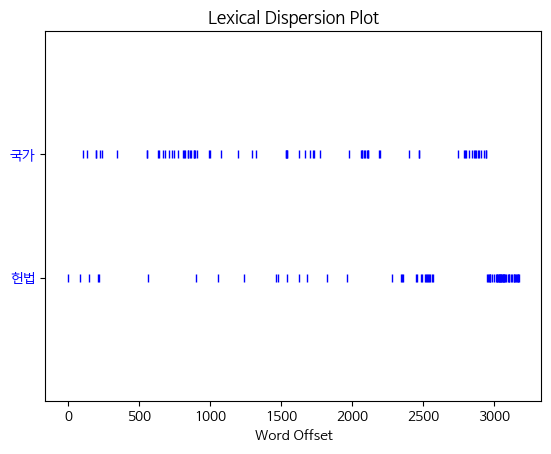

In [211]:
data_Text.dispersion_plot(['국가','헌법'])

# 6. 워드 임베딩
- 단어 간 벡터 계산 -> 단어 간 유사성 도출

In [274]:
import requests
from bs4 import BeautifulSoup
rss_url = 'https://fs.jtbc.co.kr/RSS/economy.xml'
jtbc_response = requests.get(rss_url)
soup = BeautifulSoup(jtbc_response.content,'xml')
link_el = soup.select('item link')
link_list = [el.text for el in link_el]

In [275]:
print(len(link_list))

20


In [ ]:
'''각 link들의 뉴스 기사 -> 명사만 : 
    [['둔촌','재건축','명사1','명사2'....],['실제','완전','사기','명사2'....],...]
'''

In [279]:
# 사용할 urls
from mecab import MeCab
mecab = MeCab()
news = []
urls = link_list
for url in urls :
    resp = requests.get(url)
    soup = BeautifulSoup(resp.text, 'html.parser')
    title = soup.select_one('title').text.replace('뉴스','').replace('앵커','')
    description = str(soup.select_one('meta[name="description"]')).replace('뉴스','').replace('앵커','')
    noun_list = mecab.nouns(title + ' ' + description)
    news.append(noun_list)

In [280]:
print(news)

[['둔촌', '주공', '전세', '홍수', '예상', '눈치', '게임', '시작', '단군', '이래', '최대', '규모', '재건축', '둔촌', '주공', '아파트', '입주', '다음', '달', '말', '시작', '규모', '입주', '전세', '매물', '현장'], ['실제', '캠', '핑장', '관리', '소홀', '캠', '핑장', '예약', '때', '예약', '플랫폼', '사진', '땐', '기대', '사진', '당황', '분', '캠', '핑장'], ['요즘', '끼', '편의점', '정도', '줄', '만', '원', '육박', '점심', '값', '편의점', '도시락', '끼', '때', '편의점', '도시락', '원', '식비', '부담'], ['오늘', '말', '이유', '편의점', '도시락', '천', '원', '시대', '주머니', '직장인', '자취생', '게', '편의점', '도시락', '편의점', '도시락', '천', '원', '눈앞', '아람', '기자'], ['경영', '분쟁', '주총', '표', '대결', '롤러코스터', '고려', '아연', '주가', '오늘', '일', '고려', '아연', '주가', '장중', '포인트', '말', '롤러코스터', '달', '공개매수', '절차', '마무리', '뚜껑'], ['결혼', '돈', '걱정', '예비', '부부', '저출산', '문제', '결혼', '것', '현실', '예비', '부부', '결혼식', '비용', '것', '문제', '말', '소식', '아람', '기자'], ['예비', '부부', '웨딩', '물가', '올해', '예식장', '비용', '한편', '결혼식', '비용', '것', '예비', '부부', '말', '소식', '아람', '기자', '기자', '내년', '월', '결혼'], ['대', '비정규직', '비중', '역대', '최고', '명', '중', '명', '꼴', '대', '비정규직', '임금', '근로자', '명', '중', '명', 

## JTBC RSS 활용 데이터 추출
- rss의 title과 description => 명사 추출 => 워드 임베딩(단어 간 거리 계산) => 특정 단어의 유사도

In [302]:
import requests
from mecab import MeCab
from konlpy.tag import Hannanum, Okt
from bs4 import BeautifulSoup
news = []
okt = Okt()
rss_url = 'https://fs.jtbc.co.kr/RSS/economy.xml'
jtbc_response = requests.get(rss_url)
soup = BeautifulSoup(jtbc_response.content,'xml')
items = soup.find_all('item')
for item in items :
    title = item.find('title').text
    description = item.find('description').text
    article = (title + ' ' + description).replace('[앵커]',' ').replace('[기자]',' ')
    noun_list = okt.nouns(article)
#     noun_list2 = [noun for noun, tag in okt.pos(article) if tag in ['NC','NQ']]
    news.append(noun_list)

In [303]:
news

[['둔촌',
  '공',
  '전세',
  '홍수',
  '예상',
  '눈치',
  '게임',
  '시작',
  '단군',
  '최대',
  '규모',
  '재건축',
  '둔촌',
  '아파트',
  '입',
  '주가',
  '다음',
  '달',
  '말',
  '시작',
  '번',
  '대규모',
  '입',
  '주가',
  '전세',
  '매물도',
  '현장',
  '분위기',
  '이'],
 ['실제',
  '완전',
  '사기',
  '캠핑장',
  '관리',
  '캠핑장',
  '예약',
  '때',
  '예약',
  '플랫폼',
  '사진',
  '보고',
  '막상',
  '실제',
  '달라',
  '불만',
  '경우',
  '앞',
  '예약',
  '플랫폼',
  '책임',
  '강화',
  '정아',
  '람',
  '기자',
  '인터넷',
  '카페'],
 ['요즘',
  '끼',
  '편의점',
  '이',
  '정도',
  '일',
  '줄',
  '원',
  '육박',
  '점심',
  '값',
  '편의점',
  '도시락',
  '끼',
  '때',
  '이',
  '편의점',
  '도시락',
  '식비',
  '부담',
  '정아',
  '람',
  '기자',
  '서울'],
 ['오늘',
  '말',
  '이유',
  '편의점',
  '도시락',
  '시대',
  '주머니',
  '직장인',
  '자취',
  '생',
  '자주',
  '게',
  '편의점',
  '도시락',
  '이',
  '편의점',
  '도시락',
  '눈앞',
  '정아',
  '람',
  '기자',
  '서울',
  '편의점',
  '도시락'],
 ['경영',
  '분쟁',
  '총',
  '표',
  '대결',
  '로',
  '롤러코스터',
  '고려아연',
  '주가',
  '오늘',
  '고려아연',
  '주가',
  '장',
  '포인트',
  '말',
  '그대로',
  '롤러코스터',
  '달',
  '이어진',
  '공개

## gensim 워드 임베딩

In [324]:
# 워드 임베딩 (단어 간 거리 계산)
# pip install gensim
from gensim.models import Word2Vec
model = Word2Vec(news, # 학습 데이터 2차원
                window = 10, # 각 단어의 앞뒤 10개 단어를 학습 컨텐츠로 사용
                 min_count = 2, # 학습 데이터에서 2회 이상 등장 시 학습.
                 workers = -1, # 병렬처리 코어core 수. -1 : 모든 가용 코어 사용
                )

In [330]:
model.wv.most_similar('벌써')

[('전국', 0.28148186206817627),
 ('걸', 0.2373029738664627),
 ('둔촌', 0.21424752473831177),
 ('업체', 0.2018326222896576),
 ('오늘', 0.20115292072296143),
 ('위메프', 0.19082055985927582),
 ('소식', 0.18480396270751953),
 ('기준', 0.18379682302474976),
 ('사상', 0.1757746785879135),
 ('책정', 0.164261132478714)]

In [326]:
model.wv.most_similar('아파트',topn=3)

[('람', 0.2853359878063202),
 ('대출', 0.27049094438552856),
 ('비용', 0.25984397530555725)]